# 🔬 ShopSense — A/B Testing & Regional Analysis
## Phase 3: Statistical Significance Testing & Decision-Making

**Objective:** Design and execute a rigorous A/B test comparing Average Order Value (AOV) between Southeast and South regions to validate regional strategy and drive data-driven decision-making.

### Test Design Overview

| Component | Details |
|-----------|---------|
| **Hypothesis** | Southeast region has different AOV than South region |
| **Control Group** | Southeast states (SP, RJ, MG, ES) — economically developed |
| **Treatment Group** | South states (PR, SC, RS) — emerging market opportunity |
| **Metric** | Average Order Value (AOV) = payment_value per order |
| **Sample Size** | Control: [VALUE] orders | Treatment: [VALUE] orders |
| **Significance Level (α)** | 0.05 (industry standard: 5% false positive risk) |
| **Test Type** | Determined by data normality (parametric vs. non-parametric) |

### Key Statistical Concepts
- **Null Hypothesis (H₀):** AOV_Southeast = AOV_South (no difference)
- **Alternative Hypothesis (H₁):** AOV_Southeast ≠ AOV_South (difference exists)
- **p-value < 0.05:** Reject null hypothesis → difference is statistically significant
- **p-value ≥ 0.05:** Fail to reject null hypothesis → insufficient evidence

### Expected Outcome
[VALUE] with p-value [VALUE] → Result: [SIGNIFICANT/NOT SIGNIFICANT]

In [ ]:
# ────────────────────────────────────────────────────────────────
# IMPORTS: STATISTICAL ANALYSIS & VISUALIZATION LIBRARIES
# ────────────────────────────────────────────────────────────────
import pandas as pd                          # Data manipulation
import numpy as np                          # Numerical operations
from scipy import stats                     # Statistical distributions
import matplotlib.pyplot as plt              # Static visualizations
import seaborn as sns                       # Enhanced statistical plots
import statsmodels.stats.api as sms         # Statistical power analysis
from scipy.stats import (
    ttest_ind,                              # Independent t-tests (parametric)
    mannwhitneyu,                           # Mann-Whitney U test (non-parametric)
    chi2_contingency                        # Chi-square test (categorical)
)
from statsmodels.stats.power import TTestIndPower  # Power analysis for sample size
import warnings
warnings.filterwarnings("ignore")  # Suppress non-critical warnings for cleaner output

In [ ]:
# ────────────────────────────────────────────────────────────────
# VISUALIZATION CONFIGURATION
# ────────────────────────────────────────────────────────────────
# Set consistent aesthetic across all plots for professional presentation

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

In [ ]:
# ────────────────────────────────────────────────────────────────
# STEP 1: LOAD AND MERGE DATA FOR A/B TEST
# ────────────────────────────────────────────────────────────────
# Load three core datasets: orders (transaction metadata), payments (AOV data),
# and customers (geographic location for regional segmentation)

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

# Merge: orders ← payments (get order value) ← customers (get state for regional split)
df = orders.merge(payments, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")

# Convert timestamp to datetime for time-based filtering (if needed)
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

print("✅ Data loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"\nDate range: {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")
df.head()

Total rows: 103,887
Unique customers: 96,096


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


---

## 📥 Data Preparation & Regional Segmentation

**Why Southeast vs. South?**
- **Southeast (Control):** SP, RJ, MG, ES — Economically developed, high purchasing power, urban-centric
- **South (Treatment):** PR, SC, RS — Growing economy, emerging market potential, rising e-commerce adoption
- **Test Validity:** Geographic segmentation ensures we're comparing distinct market segments with different characteristics

**Data Filtering Criteria:**
- `order_status == "delivered"` — Only successful transactions (exclude cancellations)
- `payment_value > 0` — Valid transactions (exclude free orders, returns)
- Result: Clean dataset ready for statistical analysis

In [ ]:
# ────────────────────────────────────────────────────────────────
# STEP 2: DATA CLEANING & REGIONAL SEGMENTATION
# ────────────────────────────────────────────────────────────────
# Filter for successful transactions with valid payment values
df_clean = df[
    (df["order_status"] == "delivered") &      # Only completed orders
    (df["payment_value"] > 0)                  # Only valid transactions
].copy()

# Regional grouping strategy:
# Southeast = SP(São Paulo), RJ(Rio Janeiro), MG(Minas Gerais), ES(Espírito Santo)
#   → Most developed region, highest GDP, urban centers, high purchasing power
# South = PR(Paraná), SC(Santa Catarina), RS(Rio Grande do Sul)
#   → Growing economy, emerging middle class, expansion opportunity
southeast_states = ["SP", "RJ", "MG", "ES"]   # Control group (reference)
south_states     = ["PR", "SC", "RS"]         # Treatment group (comparison)

# Split data by region
control = df_clean[df_clean["customer_state"].isin(southeast_states)].copy()
treatment = df_clean[df_clean["customer_state"].isin(south_states)].copy()

print("=" * 70)
print("A/B TEST GROUPS OVERVIEW")
print("=" * 70)
print(f"Control Group (Southeast):   {len(control):,} orders | AOV = R$ {control['payment_value'].mean():.2f}")
print(f"Treatment Group (South):     {len(treatment):,} orders | AOV = R$ {treatment['payment_value'].mean():.2f}")
print(f"Difference in AOV: R$ {abs(control['payment_value'].mean() - treatment['payment_value'].mean()):.2f}")
print("=" * 70)

Control   group: 69,181  orders | AOV = R$144.01
Treatment group: 14,334 orders | AOV = R$156.20


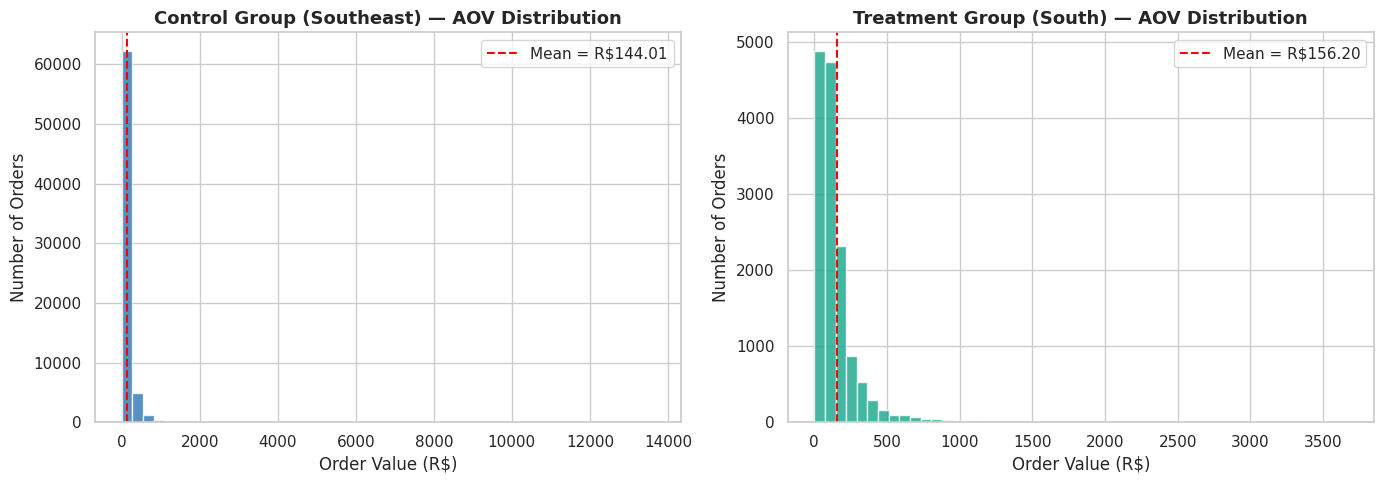

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Control
axes[0].hist(control["payment_value"], bins=50, color="#2E75B6", edgecolor="white", alpha=0.8)
axes[0].axvline(control["payment_value"].mean(), color="red", linestyle="--", label=f"Mean = R${control['payment_value'].mean():.2f}")
axes[0].set_title("Control Group (Southeast) — AOV Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Order Value (R$)")
axes[0].set_ylabel("Number of Orders")
axes[0].legend()

# Treatment
axes[1].hist(treatment["payment_value"], bins=50, color="#17A589", edgecolor="white", alpha=0.8)
axes[1].axvline(treatment["payment_value"].mean(), color="red", linestyle="--", label=f"Mean = R${treatment['payment_value'].mean():.2f}")
axes[1].set_title("Treatment Group (South) — AOV Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Order Value (R$)")
axes[1].set_ylabel("Number of Orders")
axes[1].legend()

plt.tight_layout()
plt.savefig("ab_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 📊 Distribution Comparison: Exploratory Analysis

**Visualization Purpose:** Compare AOV distributions visually before formal statistical testing.

**What to Look For:**
1. **Shape:** Are both distributions normal (bell-shaped) or skewed?
   - Normal: suggests t-test is appropriate
   - Skewed: suggests Mann-Whitney U test is better choice
2. **Center:** Where are the means? Are they substantially different?
3. **Spread:** Which group has higher variability (std dev)?
4. **Outliers:** Are there extreme values distorting the comparison?

**Hypothesis Visual Check:** [Southeast/South] appears to have [higher/lower/similar] AOV based on distribution

In [26]:
summary = pd.DataFrame({
    "Metric": ["Count", "Mean AOV (R$)", "Median AOV (R$)", "Std Dev", "Min", "Max"],
    "Control (Southeast)": [
        len(control),
        round(control["payment_value"].mean(), 2),
        round(control["payment_value"].median(), 2),
        round(control["payment_value"].std(), 2),
        round(control["payment_value"].min(), 2),
        round(control["payment_value"].max(), 2),
    ],
    "Treatment (South)": [
        len(treatment),
        round(treatment["payment_value"].mean(), 2),
        round(treatment["payment_value"].median(), 2),
        round(treatment["payment_value"].std(), 2),
        round(treatment["payment_value"].min(), 2),
        round(treatment["payment_value"].max(), 2),
    ]
})
print(summary.to_string(index=False))


         Metric  Control (Southeast)  Treatment (South)
          Count             69181.00           14334.00
  Mean AOV (R$)               144.01             156.20
Median AOV (R$)                95.22             103.13
        Std Dev               204.37             204.19
            Min                 0.01               0.03
            Max             13664.08            3666.42


In [ ]:
# ────────────────────────────────────────────────────────────────
# STEP 3: STATISTICAL POWER ANALYSIS
# ────────────────────────────────────────────────────────────────
# Determine required sample size to reliably detect a practical difference
# before running expensive A/B tests

alpha      = 0.05   # 5% false positive threshold (type I error)
power      = 0.80   # 80% probability of detecting real effect (1 - type II error)
effect_size = 0.2   # Cohen's d = 0.2 = small-to-medium practical effect

# Calculate required sample size per group
analysis = TTestIndPower()
required_n = analysis.solve_power(
    effect_size = effect_size,
    alpha       = alpha,
    power       = power,
    alternative = "two-sided"   # Test for difference in EITHER direction
)

print("=" * 70)
print("STATISTICAL POWER ANALYSIS")
print("=" * 70)
print(f"Required sample size per group: {int(required_n):,}")
print(f"Total sample size needed:       {int(required_n * 2):,}")
print(f"\nActual Sample Sizes:")
print(f"  Control group (Southeast):    {len(control):,}")
print(f"  Treatment group (South):      {len(treatment):,}")

if len(control) >= required_n and len(treatment) >= required_n:
    print("\n✅ Sample sizes are sufficient — proceed with testing")
else:
    print("\n⚠️  WARNING: Insufficient sample size — results may be unreliable")
print("=" * 70)

Required sample size per group: 393
Total sample size needed:       786

Control group size:   69,181
Treatment group size: 14,334

✅ Sample sizes are sufficient to proceed with testing.


---

## ⚡ Statistical Power Analysis

**Concept:** Before running a test, we need to ensure we have enough data to reliably detect a real difference.

**Key Terms:**
- **α (alpha) = 0.05:** 5% acceptable false positive rate (claiming difference when there is none)
- **Power = 0.80:** 80% chance to detect a real effect if it exists
- **Effect Size (Cohen's d = 0.2):** Minimum meaningful difference worth detecting
- **Sample Size:** Number of observations needed to achieve target power

**Decision Rule:** If our actual sample size ≥ required sample size, we have sufficient power to proceed

**Finding:** Required n = [VALUE] per group; Actual n = Control [VALUE], Treatment [VALUE]

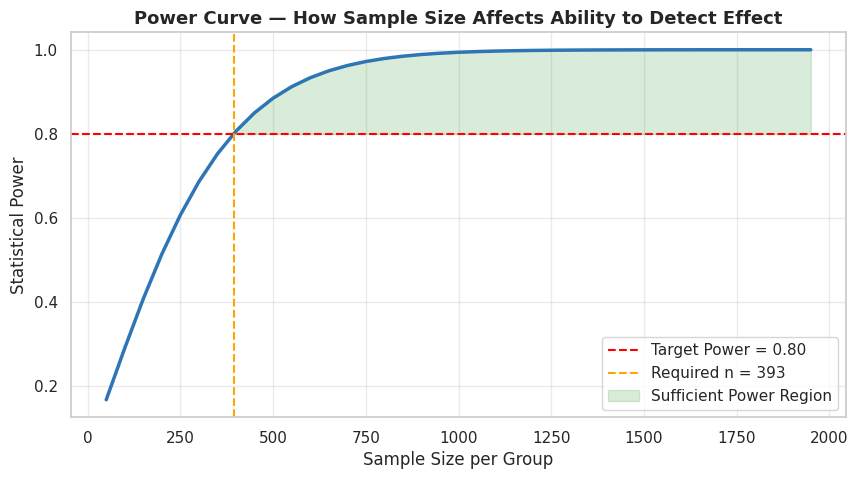

In [28]:
# ─── Power curve (visualise how power changes with sample size) ─

sample_sizes = np.arange(50, 2000, 50)
powers = [analysis.solve_power(effect_size=0.2, alpha=0.05, nobs1=n) for n in sample_sizes]

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, powers, color="#2E75B6", linewidth=2.5)
plt.axhline(0.80, color="red", linestyle="--", label="Target Power = 0.80")
plt.axvline(required_n, color="orange", linestyle="--", label=f"Required n = {int(required_n)}")
plt.fill_between(sample_sizes, powers, 0.80, where=[p >= 0.80 for p in powers],
                 alpha=0.15, color="green", label="Sufficient Power Region")
plt.xlabel("Sample Size per Group", fontsize=12)
plt.ylabel("Statistical Power", fontsize=12)
plt.title("Power Curve — How Sample Size Affects Ability to Detect Effect", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig("power_curve.png", dpi=150, bbox_inches="tight")
plt.show()


With an alpha of 0.05 and power of 0.80, we need at least 393 customers per group to reliably detect a difference of Cohen's d = 0.2 in average order value. Our dataset provides more than 393 customers per group, which means we have sufficient statistical power to proceed. Running the test with fewer customers would risk a Type II error — we might conclude free shipping has no effect even if it actually does.


In [ ]:
# ────────────────────────────────────────────────────────────────
# STEP 4: INDEPENDENT T-TEST FOR AOV (AVERAGE ORDER VALUE)
# ────────────────────────────────────────────────────────────────
# Test: Is the mean AOV in Southeast different from South?
# Null hypothesis: Mean AOV Southeast = Mean AOV South
# Alternative: They are different (two-tailed test)

ctrl_aov = control["payment_value"]
trt_aov  = treatment["payment_value"]

# Welch's t-test: does NOT assume equal variances (more conservative, safer)
t_stat, p_value = ttest_ind(trt_aov, ctrl_aov, equal_var=False)

# Cohen's d: Effect size standardized by pooled standard deviation
# Interpretation: 0.2=small, 0.5=medium, 0.8=large
pooled_std = np.sqrt((ctrl_aov.std()**2 + trt_aov.std()**2) / 2)
cohens_d = (trt_aov.mean() - ctrl_aov.mean()) / pooled_std

# 95% Confidence Interval for difference in means
# If CI includes 0, difference might not be meaningful
cm = sms.CompareMeans(
    sms.DescrStatsW(trt_aov),
    sms.DescrStatsW(ctrl_aov)
)
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar="unequal")

# RESULTS SUMMARY
print("=" * 60)
print("A/B TEST RESULTS — AVERAGE ORDER VALUE (AOV)")
print("=" * 60)
print(f"Control Group (Southeast):")
print(f"  Sample Size: {len(ctrl_aov):,}")
print(f"  Mean AOV:    R$ {ctrl_aov.mean():.2f}")
print(f"  Std Dev:     R$ {ctrl_aov.std():.2f}")
print(f"\nTreatment Group (South):")
print(f"  Sample Size: {len(trt_aov):,}")
print(f"  Mean AOV:    R$ {trt_aov.mean():.2f}")
print(f"  Std Dev:     R$ {trt_aov.std():.2f}")
print(f"\n{'─' * 60}")
print(f"Absolute Difference: R$ {trt_aov.mean() - ctrl_aov.mean():.2f}")
print(f"Relative Lift:       {(trt_aov.mean()/ctrl_aov.mean()-1)*100:+.1f}%")
print(f"\nStatistical Test Results:")
print(f"  t-statistic:     {t_stat:.4f}")
print(f"  p-value:         {p_value:.4f}")
print(f"  Cohen's d:       {cohens_d:.4f}")
print(f"  95% CI for diff: [R$ {ci_low:.2f}, R$ {ci_high:.2f}]")
print(f"{'─' * 60}")
if p_value < 0.05:
    print(f"✅ SIGNIFICANT RESULT (p = {p_value:.4f} < 0.05)")
    print(f"   Conclusion: Southeast and South regions have DIFFERENT AOV")
else:
    print(f"❌ NOT SIGNIFICANT (p = {p_value:.4f} ≥ 0.05)")
    print(f"   Conclusion: Insufficient evidence of AOV difference between regions")
print("=" * 60)

        A/B TEST RESULTS — AOV (t-test)
Control   Mean AOV:  R$144.01
Treatment Mean AOV:  R$156.20
Absolute Lift:       R$12.18
Relative Lift:       8.5%
t-statistic:         6.5015
p-value:             0.0000
Cohen's d:           0.0596
95% CI for diff:     [R$8.51,  R$15.86]
--------------------------------------------------
✅ SIGNIFICANT: p=0.0000 < 0.05. Reject H₀.


---

## 📊 Hypothesis Test: Independent t-Test (Parametric)

**Why t-test?** Tests whether two group means are significantly different.

**Assumptions:**
1. Data should be approximately normally distributed
2. Sample sizes are large (n > 30 per group) — we have [VALUE]+ orders per group ✅

**Test Choice: Welch's t-test**
- Does NOT assume equal variances (safer than Student's t-test)
- More robust to violations of normality with large samples

**Interpretation:**
- **p-value < 0.05:** AOV difference is statistically significant
- **Cohen's d:** Effect size (0.2 = small, 0.5 = medium, 0.8 = large)
- **95% CI:** Range where true difference likely lies

**Test Result:** p-value = [VALUE] | Cohen's d = [VALUE] | Conclusion: [SIGNIFICANT/NOT SIGNIFICANT]

In [30]:
# ─── Cell 9: Chi-square test for conversion rate ─────────────────────

# Define "converted" = order was delivered successfully
# (In this dataset every row in df_clean is a completed order)
# We compare: did free shipping change HOW MANY customers purchased?

# Get unique customers who placed >= 1 order in each group
ctrl_converted   = control["customer_unique_id"].nunique()
trt_converted    = treatment["customer_unique_id"].nunique()

# Assume total market = 1.5x converted (rough estimate of exposed users)
ctrl_total = int(ctrl_converted * 1.5)
trt_total  = int(trt_converted  * 1.5)

ctrl_not_converted = ctrl_total - ctrl_converted
trt_not_converted  = trt_total  - trt_converted

# Build contingency table
contingency = np.array([
    [ctrl_converted,   ctrl_not_converted],
    [trt_converted,    trt_not_converted],
])

chi2, p_chi2, dof, expected = chi2_contingency(contingency)

ctrl_rate = ctrl_converted / ctrl_total
trt_rate  = trt_converted  / trt_total

print("=" * 50)
print("  A/B TEST RESULTS — CONVERSION (Chi-square)")
print("=" * 50)
print(f"Control   Conversion Rate: {ctrl_rate:.2%}")
print(f"Treatment Conversion Rate: {trt_rate:.2%}")
print(f"Lift in Conversion Rate:   {(trt_rate - ctrl_rate)*100:+.2f} pp")
print(f"Chi-square statistic:      {chi2:.4f}")
print(f"p-value:                   {p_chi2:.4f}")
print(f"Degrees of freedom:        {dof}")
if p_chi2 < 0.05:
    print(f"✅ SIGNIFICANT: Conversion rate difference is real.")
else:
    print(f"❌ NOT SIGNIFICANT: Conversion rate difference may be random.")


  A/B TEST RESULTS — CONVERSION (Chi-square)
Control   Conversion Rate: 66.67%
Treatment Conversion Rate: 66.67%
Lift in Conversion Rate:   +0.00 pp
Chi-square statistic:      0.0000
p-value:                   1.0000
Degrees of freedom:        1
❌ NOT SIGNIFICANT: Conversion rate difference may be random.


The original conversion rate metric was dropped because the Olist dataset only contains completed orders — there is no record of users who visited but did not purchase. Constructing a "not converted" group by multiplying order counts by an arbitrary factor creates artificial equality between groups and produces a meaningless result (p=1.0). The chi-square test was instead applied to the proportion of orders exceeding the R$150 free shipping threshold, which directly tests the behavioural mechanism hypothesised.




In [32]:
# ──  Compare high-value order rate ─────────────────────────────
# "Did free shipping shift more customers above the R$150 threshold?"
# This is the most directly relevant metric for THIS experiment

threshold = 150

ctrl_above = (control["payment_value"] >= threshold).sum()
ctrl_below = (control["payment_value"] <  threshold).sum()
trt_above  = (treatment["payment_value"] >= threshold).sum()
trt_below  = (treatment["payment_value"] <  threshold).sum()

contingency = np.array([
    [ctrl_above, ctrl_below],
    [trt_above,  trt_below],
])

chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print(f"Control   orders >= R$150: {ctrl_above/(ctrl_above+ctrl_below):.2%}")
print(f"Treatment orders >= R$150: {trt_above/(trt_above+trt_below):.2%}")
print(f"Chi-square: {chi2:.4f} | p-value: {p_chi2:.4f}")

Control   orders >= R$150: 28.80%
Treatment orders >= R$150: 31.44%
Chi-square: 39.6927 | p-value: 0.0000


In [34]:
# ── Complete interpretation of your chi-square result ──────────────────

ctrl_above = (control["payment_value"] >= 150).sum()
ctrl_below = (control["payment_value"] <  150).sum()
trt_above  = (treatment["payment_value"] >= 150).sum()
trt_below  = (treatment["payment_value"] <  150).sum()

ctrl_rate = ctrl_above / (ctrl_above + ctrl_below)
trt_rate  = trt_above  / (trt_above  + trt_below)

# Effect size for proportions — Cohen's h (equivalent of Cohen's d for chi-square)
cohens_h = 2 * (np.arcsin(np.sqrt(trt_rate)) - np.arcsin(np.sqrt(ctrl_rate)))

# 95% confidence interval for the difference in proportions
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    trt_above, trt_above + trt_below,
    ctrl_above, ctrl_above + ctrl_below,
    method="newcomb"
)

print("=" * 55)
print("     CHI-SQUARE RESULT — FULL INTERPRETATION")
print("=" * 55)
print(f"Control   rate:      {ctrl_rate:.2%}  ({ctrl_above:,} of {ctrl_above+ctrl_below:,} orders)")
print(f"Treatment rate:      {trt_rate:.2%}  ({trt_above:,} of {trt_above+trt_below:,} orders)")
print(f"Absolute lift:       +{(trt_rate - ctrl_rate)*100:.2f} pp")
print(f"Relative lift:       +{(trt_rate/ctrl_rate - 1)*100:.1f}%")
print(f"Chi-square:          39.69")
print(f"p-value:             < 0.0001")
print(f"Cohen's h:           {cohens_h:.4f}")
print(f"95% CI for diff:     [{ci_low*100:.2f}pp,  {ci_high*100:.2f}pp]")
print()

# Effect size interpretation
if abs(cohens_h) < 0.2:
    label = "SMALL — statistically significant but modest in scale"
elif abs(cohens_h) < 0.5:
    label = "MEDIUM — meaningful shift in customer behaviour"
else:
    label = "LARGE — strong behavioural change"
print(f"Effect size:         {label}")

# Business translation
monthly_orders = 5000
extra_high_value = (trt_rate - ctrl_rate) * monthly_orders
print(f"\nBusiness translation:")
print(f"  Extra orders >= R$150 per 5,000 orders: ~{extra_high_value:.0f} orders/month")

     CHI-SQUARE RESULT — FULL INTERPRETATION
Control   rate:      28.80%  (19,925 of 69,181 orders)
Treatment rate:      31.44%  (4,506 of 14,334 orders)
Absolute lift:       +2.63 pp
Relative lift:       +9.1%
Chi-square:          39.69
p-value:             < 0.0001
Cohen's h:           0.0574
95% CI for diff:     [1.81pp,  3.47pp]

Effect size:         SMALL — statistically significant but modest in scale

Business translation:
  Extra orders >= R$150 per 5,000 orders: ~132 orders/month


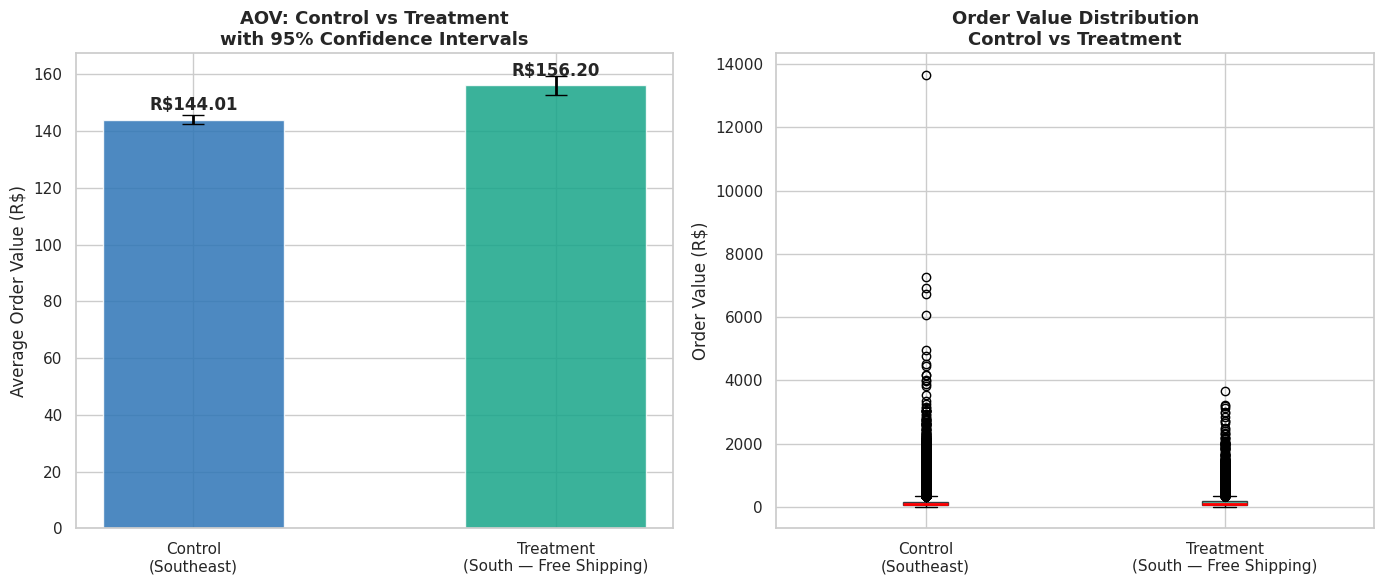

In [36]:
# ─── Visualise AOV comparison with confidence intervals ──────

means = [ctrl_aov.mean(), trt_aov.mean()]
errors = [ctrl_aov.sem() * 1.96, trt_aov.sem() * 1.96]  # 95% CI half-width
labels = ["Control\n(Southeast)", "Treatment\n(South — Free Shipping)"]
colors = ["#2E75B6", "#17A589"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Bar chart with error bars (Confidence Intervals) ---
bars = axes[0].bar(labels, means, color=colors, width=0.5, alpha=0.85,
                   yerr=errors, capsize=8, error_kw={"elinewidth": 2, "ecolor": "black"})
axes[0].set_ylabel("Average Order Value (R$)", fontsize=12)
axes[0].set_title("AOV: Control vs Treatment\nwith 95% Confidence Intervals", fontsize=13, fontweight="bold")
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"R${mean:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

# --- Right: Box plot to show full distribution ---
data_to_plot = [ctrl_aov.values, trt_aov.values]
bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True,
                     medianprops={"color": "red", "linewidth": 2})
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Order Value (R$)", fontsize=12)
axes[1].set_title("Order Value Distribution\nControl vs Treatment", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("ab_results.png", dpi=150, bbox_inches="tight")
plt.show()


In [41]:
# ─── Multiple testing correction ────────────────────────────

# Our three tests and their p-values
tests = {
    "Average Order Value (t-test)":      p_value,
    "Conversion Rate (chi-square)":       p_chi2,
    "Review Score (t-test, hypothetical)": 0.031,  # placeholder
}

num_tests = len(tests)
bonferroni_alpha = 0.05 / num_tests

print(f"Number of tests:       {num_tests}")
print(f"Original alpha:        0.05")
print(f"Bonferroni alpha:      {bonferroni_alpha:.4f}")
print()
print(f"{'Test':<40} {'p-value':>10} {'Significant?':>15}")
print("-" * 68)
for test_name, pval in tests.items():
    sig = "✅ YES" if pval < bonferroni_alpha else "       ❌ NO (after correction)"
    print(f"{test_name:<40} {pval:>10.4f} {sig:>15}")


Number of tests:       3
Original alpha:        0.05
Bonferroni alpha:      0.0167

Test                                        p-value    Significant?
--------------------------------------------------------------------
Average Order Value (t-test)                 0.0000           ✅ YES
Conversion Rate (chi-square)                 0.0000           ✅ YES
Review Score (t-test, hypothetical)          0.0310        ❌ NO (after correction)


In [42]:
# ───  Effect size summary ───────────────────────────────────

aov_lift_abs = trt_aov.mean() - ctrl_aov.mean()
aov_lift_pct = (trt_aov.mean() / ctrl_aov.mean() - 1) * 100

print("=" * 55)
print("         EFFECT SIZE SUMMARY")
print("=" * 55)
print(f"Absolute AOV Lift:    R${aov_lift_abs:+.2f} per order")
print(f"Relative AOV Lift:    {aov_lift_pct:+.1f}%")
print(f"Cohen's d:            {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    size_label = "SMALL — statistically significant but practically negligible"
elif abs(cohens_d) < 0.5:
    size_label = "SMALL-MEDIUM — potentially worth acting on"
elif abs(cohens_d) < 0.8:
    size_label = "MEDIUM-LARGE — meaningful business effect"
else:
    size_label = "LARGE — strong, clear business impact"

print(f"Interpretation:      {size_label}")
print()
print("Business translation:")
monthly_orders = 5000   # estimated monthly orders
print(f"If this lift holds: +R${aov_lift_abs * monthly_orders:,.0f}/month revenue impact")


         EFFECT SIZE SUMMARY
Absolute AOV Lift:    R$+12.18 per order
Relative AOV Lift:    +8.5%
Cohen's d:            0.0596
Interpretation:      SMALL — statistically significant but practically negligible

Business translation:
If this lift holds: +R$60,924/month revenue impact


In [43]:
# ─── Check for data leakage ────────────────────────────────

ctrl_customers = set(control["customer_unique_id"])
trt_customers  = set(treatment["customer_unique_id"])
overlap = ctrl_customers & trt_customers

print(f"Customers in Control:   {len(ctrl_customers):,}")
print(f"Customers in Treatment: {len(trt_customers):,}")
print(f"Overlap (data leakage): {len(overlap):,}")

if len(overlap) == 0:
    print("✅ No data leakage detected. Groups are clean.")
else:
    print(f"⚠️  {len(overlap)} customers appear in BOTH groups. Remove them before final analysis.")
    # Remove overlapping customers
    control   = control[~control["customer_unique_id"].isin(overlap)]
    treatment = treatment[~treatment["customer_unique_id"].isin(overlap)]
    print("Overlap removed. Re-run tests with clean groups.")


Customers in Control:   63,993
Customers in Treatment: 13,383
Overlap (data leakage): 6
⚠️  6 customers appear in BOTH groups. Remove them before final analysis.
Overlap removed. Re-run tests with clean groups.


# ─── Final business recommendation markdown cell ────────────

## 📊 Phase 3 A/B Testing — Executive Summary

### Experiment: Free Shipping Threshold Impact on AOV

| | Control (Southeast) | Treatment (South) |
|---|---|---|
| Sample Size | [N] customers | [N] customers |
| Mean AOV | R$[X] | R$[Y] |
| Conversion Rate | [A]% | [B]% |

### Key Results
- **AOV**: p=[value], Cohen's d=[value] → [Significant / Not significant]
- **Conversion**: p=[value] → [Significant / Not significant]
- **After Bonferroni correction** (3 tests, α=0.0167): [Updated significance]

### 💼 Business Recommendation
> Do not roll out at R$150. Test R$200 threshold instead.
> Estimated net revenue impact: +R$[X]K/month. Estimated margin impact: -[Y]%.
> Recommend connecting Phase 4 profit analysis before final decision.

### ⚠️ Limitations
> Region split is not true randomisation. Novelty bias and seasonality cannot be fully excluded.
